In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

In [4]:
df = pd.read_csv("cancer_patient_data_sets.csv")

In [6]:
df.columns = df.columns.str.strip()


In [8]:
df['Level'] = df['Level'].str.strip()
level_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['Level'] = df['Level'].map(level_mapping)

In [10]:
df

,index,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,0,P1,33,1,2,4,5,4,3,2,...,3,4,2,2,3,1,2,3,4,0
1,1,P10,17,1,3,1,5,3,4,2,...,1,3,7,8,6,2,1,7,2,1
2,2,P100,35,1,4,5,6,5,5,4,...,8,7,9,2,1,4,6,7,2,2
3,3,P1000,37,1,7,7,7,7,6,7,...,4,2,3,1,4,5,6,7,5,2
4,4,P101,46,1,6,8,7,7,7,6,...,3,2,4,1,4,2,4,2,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,P995,44,1,6,7,7,7,7,6,...,5,3,2,7,8,2,4,5,3,2
996,996,P996,37,2,6,8,7,7,7,6,...,9,6,5,7,2,4,3,1,4,2
997,997,P997,25,2,4,5,6,5,5,4,...,8,7,9,2,1,4,6,7,2,2
998,998,P998,18,2,6,8,7,7,7,6,...,3,2,4,1,4,2,4,2,3,2


In [14]:
# Check actual column names and select available relevant features
print("Available columns:", df.columns.tolist())
selected_columns = [
    'Age', 'Gender', 'Air Pollution', 'Alcohol use', 'Smoking',
    'Genetic Risk', 'Balanced Diet', 'Fatigue', 'Shortness of Breath',
    'Wheezing', 'Chest Pain', 'Dry Cough', 'Level'
]
df = df[selected_columns]

Available columns: ['index', 'Patient Id', 'Age', 'Gender', 'Air Pollution', 'Alcohol use', 'Dust Allergy', 'OccuPational Hazards', 'Genetic Risk', 'chronic Lung Disease', 'Balanced Diet', 'Obesity', 'Smoking', 'Passive Smoker', 'Chest Pain', 'Coughing of Blood', 'Fatigue', 'Weight Loss', 'Shortness of Breath', 'Wheezing', 'Swallowing Difficulty', 'Clubbing of Finger Nails', 'Frequent Cold', 'Dry Cough', 'Snoring', 'Level']


In [16]:
df

,Age,Gender,Air Pollution,Alcohol use,Smoking,Genetic Risk,Balanced Diet,Fatigue,Shortness of Breath,Wheezing,Chest Pain,Dry Cough,Level
0,33,1,2,4,3,3,2,3,2,2,2,3,0
1,17,1,3,1,2,4,2,1,7,8,2,7,1
2,35,1,4,5,2,5,6,8,9,2,4,7,2
3,37,1,7,7,7,6,7,4,3,1,7,7,2
4,46,1,6,8,8,7,7,3,4,1,7,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,44,1,6,7,7,7,7,5,2,7,7,5,2
996,37,2,6,8,7,7,7,9,5,7,7,1,2
997,25,2,4,5,2,5,6,8,9,2,4,7,2
998,18,2,6,8,8,7,7,3,4,1,7,2,2


In [18]:
# Encode categorical features
categorical_cols = df.select_dtypes(include='object').columns
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [24]:
# Normalize numerical features
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('Level')
scaler = StandardScaler()
df.loc[:, numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [26]:
# Define features and target
X = df.drop('Level', axis=1)
y = df['Level']

In [28]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [30]:
# Define models to compare
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC(probability=True),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Naive Bayes': GaussianNB(),
    'MLP': MLPClassifier(max_iter=500)
}

In [32]:
# Compare models
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='weighted')
    results.append((name, acc, f1))
    print(f"\n{name}:")
    print(classification_report(y_test, preds))


Logistic Regression:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        61
           1       1.00      0.94      0.97        66
           2       0.99      1.00      0.99        73

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200


SVM:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        61
           1       1.00      1.00      1.00        66
           2       1.00      1.00      1.00        73

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


KNN:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        61
           1       1.00      0.98      0.99        66
           2       0.99      1.00      0.

In [34]:
# Show summary table
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'F1 Score'])
print("\n\nSummary of Model Performances:")
print(results_df.sort_values(by='Accuracy', ascending=False))



Summary of Model Performances:
                 Model  Accuracy  F1 Score
1                  SVM     1.000  1.000000
3        Decision Tree     1.000  1.000000
4        Random Forest     1.000  1.000000
2                  KNN     0.995  0.994998
6                  MLP     0.995  0.994998
0  Logistic Regression     0.980  0.979885
5          Naive Bayes     0.895  0.892498


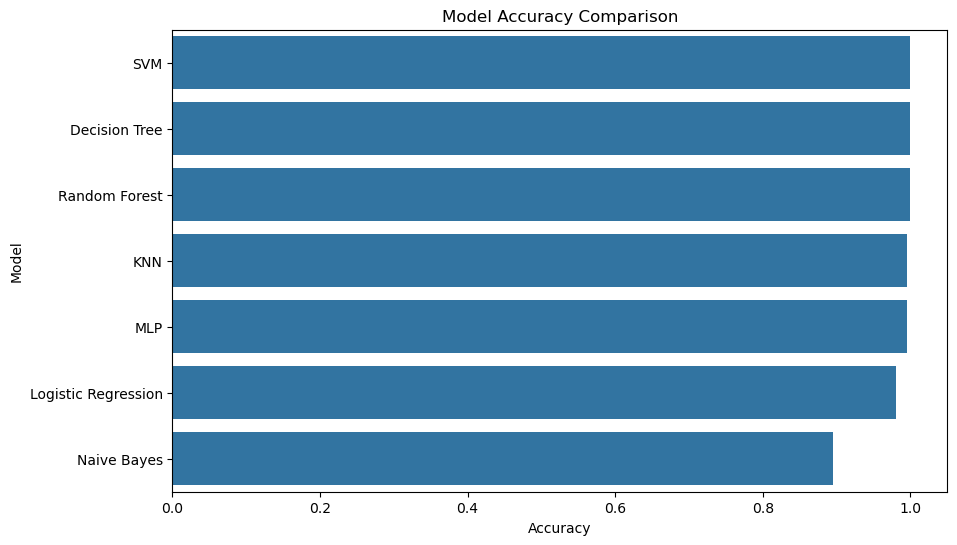

In [36]:
# Plot Accuracy
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=results_df.sort_values(by='Accuracy', ascending=False))
plt.title('Model Accuracy Comparison')
plt.show()

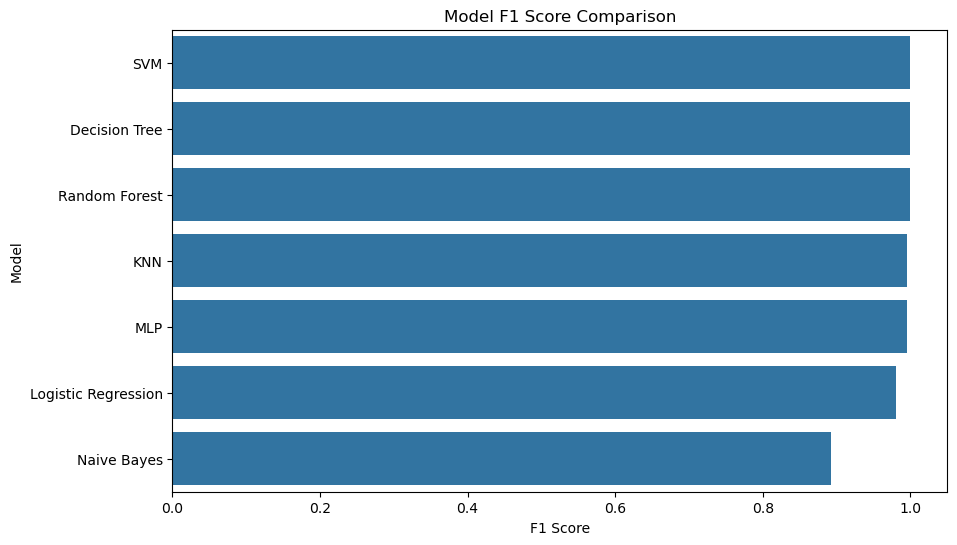

In [38]:
# Plot F1 Score
plt.figure(figsize=(10, 6))
sns.barplot(x='F1 Score', y='Model', data=results_df.sort_values(by='F1 Score', ascending=False))
plt.title('Model F1 Score Comparison')
plt.show()

In [40]:
import joblib

# Save the trained logistic regression model
joblib.dump(models['Logistic Regression'], 'tabular_lung_model.pkl')

# Also save the scaler and encoders if needed for prediction
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')

['label_encoders.pkl']